# 03 - Revisione di Statistica: L'Equazione più Pericolosa

Nel suo famoso articolo del 2007, Howard Wainer scrive di equazioni molto pericolose:

"Alcune equazioni sono pericolose se le conosci, altre lo sono se non le conosci. La prima categoria può essere pericolosa perché i segreti nascosti in essa aprono porte dietro cui si celano pericoli terribili. Il vincitore ovvio è l'iconica equazione di Einstein $E = mc^2$, perché fornisce una misura dell'enorme energia nascosta nella materia ordinaria. \[...\] Invece sono interessato a equazioni che scatenano il loro pericolo non quando sappiamo di loro, ma piuttosto quando non lo sappiamo. Tenute a portata di mano, queste equazioni ci permettono di comprendere le cose chiaramente, ma la loro assenza ci lascia pericolosamente ignoranti."

L'equazione di cui parla è l'**equazione di Moivre**:

$
SE = \dfrac{\sigma}{\sqrt{n}}
$

dove $SE$ è l'**errore standard della media**, $\sigma$ è la **deviazione standard**, e $n$ è la dimensione del campione. Sembra un pezzo di matematica che i coraggiosi e consapevoli dovrebbero padroneggiare, quindi iniziamo.

[n.d.t. standard deviation, calcolata come  $\sqrt{\dfrac{\sum_{i=1}^{n}(x_i - \bar{x})    ]^2}{n}}$, chiamata pure scarto quadratico medio ]


Per capire perché non conoscere questa equazione è molto pericoloso, esaminiamo alcuni dati sull'istruzione. Ho raccolto dati sui punteggi ENEM (punteggi standardizzati delle scuole superiori brasiliane) di diverse scuole per 3 anni. Ho pulito i dati per mantenere solo le informazioni rilevanti per noi. I dati originali possono essere scaricati dal [sito Inep](http://portal.inep.gov.br/web/guest/microdados#).

Se guardiamo la **scuola con le migliori prestazioni**, qualcosa colpisce l'occhio: quelle scuole hanno **un numero ragionevolmente piccolo di studenti**.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")
df = pd.read_csv("./data/enem_scores.csv")
df.sort_values(by="avg_score", ascending=False).head(10)

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
16668,2005,33062633,59,81.89
16794,2005,33065403,177,81.66
10043,2007,29342880,43,80.32
18121,2007,33152314,14,79.82
16781,2007,33065250,80,79.67
3026,2007,22025740,144,79.52
14636,2007,31311723,222,79.41
17318,2007,33087679,210,79.38


Guardando da un'altra prospettiva, possiamo separare solo l'1% delle scuole migliori e studiarle. Quali sono le loro caratteristiche? **Forse possiamo imparare qualcosa dalle migliori scuole** e replicarlo altrove. E infatti, se guardiamo all'1% di scuole migliori, scopriamo che hanno, in media, meno studenti.

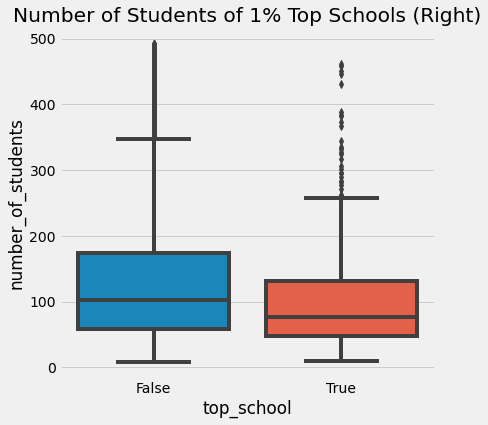

In [3]:
plot_data = (df
             .assign(top_school = df["avg_score"] >= np.quantile(df["avg_score"], .99))
             [["top_school", "number_of_students"]]
             .query(f"number_of_students<{np.quantile(df['number_of_students'], .98)}")) # remove outliers

plt.figure(figsize=(6,6))
sns.boxplot(x="top_school", y="number_of_students", data=plot_data)
plt.title("Number of Students of 1% Top Schools (Right)");

Una conclusione naturale è che le scuole piccole portano a migliori risultati accademici. Questo ha senso intuitivo poiché crediamo che meno studenti per insegnante consentano all'insegnante di prestare attenzione mirata a ciascuno studente. Ma cosa c'entra tutto questo con l'equazione di Moivre? E perché è pericoloso?

Diventa pericoloso quando le persone iniziano a prendere decisioni importanti e costose sulla base di queste informazioni. Nel suo articolo, Howard continua:

"Negli anni '90, è diventato popolare promuovere la riduzione del numero di studenti. Scuole di tutte le dimensioni hanno iniziato a ridursi o hanno smesso di crescere. E, ovviamente, uno dei fattori che la gente ha visto è che le migliori scuole tendono ad avere meno studenti \[...\] Sembra che nessuno abbia notato che **anche le peggiori scuole tendono ad avere pochi studenti**."

Questo è esattamente il problema di non conoscere l'equazione di Moivre!

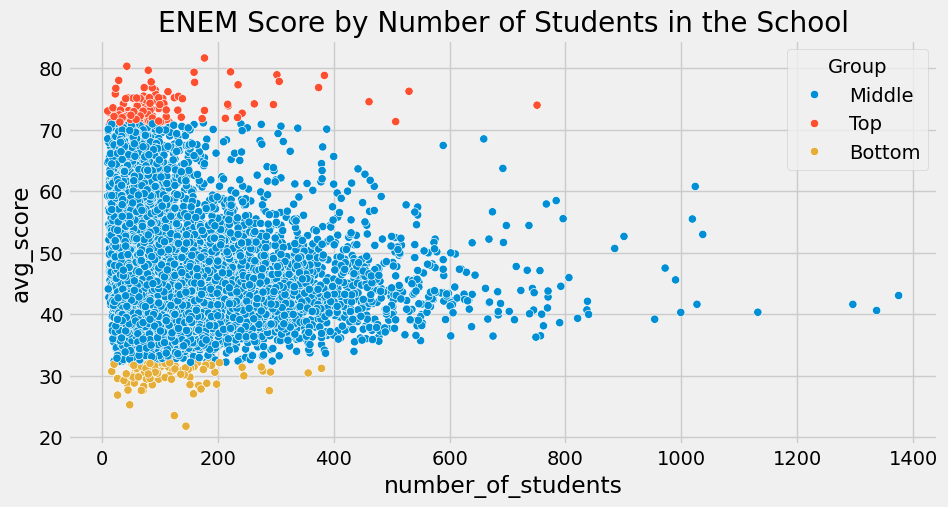

In [6]:
q_99 = np.quantile(df["avg_score"], .99)
q_01 = np.quantile(df["avg_score"], .01)

plot_data = (df
             .sample(10000)
             .assign(Group = lambda d: np.select([d["avg_score"] > q_99, d["avg_score"] < q_01],
                                                 ["Top", "Bottom"], "Middle")))
plt.figure(figsize=(10,5))
sns.scatterplot(y="avg_score", x="number_of_students", hue="Group", data=plot_data)
plt.title("ENEM Score by Number of Students in the School");

Stiamo vedendo sopra esattamente quello che ci aspettiamo secondo l'equazione di Moivre. **Man mano che il numero di studenti aumenta, il punteggio medio diventa sempre più preciso**. Le scuole con pochissimi campioni possono avere **punteggi molto alti e bassi semplicemente per caso**. Questo è meno probabile che accada in scuole grandi. L'equazione di Moivre parla di un fatto fondamentale sulla realtà dell'informazione e dei dati: è sempre imprecisa. La domanda allora diventa quanto imprecisa.

La **statistica** è la scienza di affrontare questa imprecisione. E gran parte di questa scienza consiste nel **capire come utilizzare dati limitati per fare buone stime**.

Stiamo vedendo sopra esattamente quello che ci aspettiamo secondo l'equazione di Moivre. Man mano che il numero di studenti aumenta, il punteggio medio diventa sempre più preciso. Le scuole con pochissimi campioni possono avere punteggi molto alti e bassi semplicemente per caso. Questo è meno probabile che accada in scuole grandi. L'equazione di Moivre parla di un fatto fondamentale sulla realtà dell'informazione e dei dati: è sempre imprecisa. La domanda allora diventa quanto imprecisa.

La statistica è la scienza di affrontare questa imprecisione. E gran parte di questa scienza consiste nel capire come utilizzare dati limitati per fare buone stime.



Statistics is the science that deals with these imprecisions, so they don’t catch us off-guard. As Taleb puts it in his book, Fooled by Randomness:

    Probability is not a mere computation of odds on the dice or more complicated variants; it is the acceptance of the lack of certainty in our knowledge and the development of methods for dealing with our ignorance.

One way to quantify our uncertainty is the variance of our estimates. Variance tells us how much observation deviates from its central and most probable value. As Moivre’s equation indicates, this uncertainty shrinks as the amount of data we observe increases. This makes sense, right? If we see many students performing excellently at a school, we can be more confident that this is indeed a good school. However, if we see a school with only 10 students and 8 of them perform well, we need to be more suspicious. By chance, it could be that the school got some above-average students.

The beautiful triangular plot we see above tells precisely this story. It shows us how our estimates of the school performance have a huge variance when the sample sizes are small. It also indicates that variance shrinks as the sample size increases. This is true for the average score in a school, but it is also true about any summary statistics we have, including the ATE we often want to estimate.






## Confidence Intervals

The standard error of our estimate is a measure of confidence. We need to go into turbulent and polemic statistical waters to understand precisely what it means. For one view of statistics, the frequentist view, we would say that our data is nothing more than a manifestation of an accurate data-generating process. This process is abstract and ideal. It is governed by true parameters that are unchanging but also unknown to us. In the context of the students' test, if we could run multiple experiments and collect multiple datasets, all would resemble the true underlying data generating process but wouldn't be exactly like it. This is very much like Plato's writing on the Forms:

> Each [of the essential forms] manifests itself in a great variety of combinations, with actions, with material things, and with one another, and each seems to be many

Let's suppose we have a true abstract distribution of students' test scores to better grasp this. This is a normal distribution with a true mean of 74 and a true standard deviation of 2. From this distribution, we can run 10000 experiments. On each one, we collect 500 samples. If we plot them in a histogram, we can see that means of the experiments are distributed around the true mean. Some experiment data will have a mean lower than the true one, and some will be higher.

## Intervalli di Confidenza

L'errore standard della nostra stima è una misura di confidenza. Dobbiamo addentrarci in acque turbolente e polemiche della statistica per comprendere precisamente cosa significhi. Per una visione della statistica, la **visione frequentista**, diremmo che i nostri dati non sono niente più che una manifestazione di un processo di generazione dei dati accurato. Questo processo è astratto e ideale. È governato da parametri veri che sono immutabili ma anche sconosciuti a noi. Nel contesto del test degli studenti, se potessimo eseguire l'esperimento infinitamente molte volte, il valore medio sarebbe il nostro vero parametro.

Notice that we are talking about the mean of means here. So, by chance, we could have an experiment where the mean is somewhat below or above the true mean. This is to say that we can never be sure that the mean of our experiment matches the true platonic and ideal mean. However, **with the standard error, we can create an interval that will contain the true mean 95% of the time**.

In real life, we don't have the luxury of simulating the same experiment with multiple datasets. We often only have one. But we can draw on the intuition above to construct what we call **confidence intervals**. Confidence intervals come with a probability attached to them. The most common one is 95%. This probability tells us how many hypothetical confidence intervals we would build from different studies contain the true mean. For example, the 95% confidence intervals computed from similar studies would include the true mean 95% of the time. 

To calculate the confidence interval, we use the **central limit theorem**. This theorem states that **means of experiments are normally distributed**. From statistical theory, we know that 95% of the mass of a normal distribution is between 2 standard deviations above and below the mean. Technically, 1.96, but 2 is close enough. 

![normal_density](./data/img/stats-review/normal_dist.jpeg)

The Standard Error of the mean serves as our estimate of the distribution of the experiment means. So, if we multiply it by 2 and add and subtract it from the mean of one of our experiments, we will construct a 95% confidence interval for the true mean.

Nota che stiamo parlando della media delle medie qui. Quindi, per caso, potremmo avere un esperimento dove la media è alquanto al di sotto o al di sopra della vera media. Ciò significa che non possiamo mai essere certi che la media del nostro esperimento corrisponda alla vera media platonica e ideale. Tuttavia, **con l'errore standard, possiamo creare un intervallo che conterrà la vera media il 95% delle volte**.

Nella vita reale, non abbiamo il lusso di simulare lo stesso esperimento con più set di dati. Spesso abbiamo solo un set di dati. Fortunatamente, i matematici hanno dimostrato che un singolo campione è sufficiente e il suo errore standard è una buona stima di quanto sarebbe variabile.

Of course, we don't need to restrict ourselves to the 95% confidence interval. We could generate the 99% interval by finding what we need to multiply the standard deviation by so the interval contains 99% of the mass of a normal distribution. 

The function `ppf` in python gives us the inverse of the CDF. Instead of multiplying the standard error by 2 like we did to find the 95% CI, we will multiply it by `z`, which will result in the 99% CI. So, `ppf(0.5)` will return 0.0, saying that 50% of the mass of the standard normal distribution (mean 0 and 1 standard deviation) is below 0.0. By the same token, if we plug 99.5%, we will have the value `z`, such that 99.5% of the distribution mass falls below this value. In other words, 0.5% of the mass falls above this value.

Naturalmente, non abbiamo bisogno di limitarci all'intervallo di confidenza del 95%. Potremmo generare l'intervallo del 99% trovando per cosa moltiplicare la deviazione standard in modo che l'intervallo contenga il 99% della massa di una distribuzione normale.

La funzione `ppf` in python ci dà l'inverso della CDF. Invece di moltiplicare l'errore standard per 2 come abbiamo fatto per trovare il CI del 95%, lo moltiplicare per `z`, che risulterà nel CI del 99%. Quindi, `ppf(0.5)` restituirà 0.0, dicendo che il 50% della distribuzione è al di sotto di questo valore.

Back to our classroom experiment, we can construct the confidence interval for the mean exam score for both the online and face to face students' group

Tornando al nostro esperimento in classe, possiamo costruire l'intervallo di confidenza per il punteggio medio dell'esame sia per gli studenti online che per il gruppo faccia a faccia

We can see that the 95% CIs of the groups don't overlap. The lower end of the CI for Face to Face class is above the upper end of the CI for online classes. This is evidence that our result is not by chance and that the true mean for students in face-to-face classes is higher than the true mean for students in online classes. In other words, there is a significant causal decrease in academic performance when switching from face-to-face to online classes.

To recap, confidence intervals are a way to place uncertainty around our estimates. The smaller the sample size, the larger the standard error, and the wider the confidence interval. Since they are super easy to compute, lack of confidence intervals signals either some bad intentions or simply lack of knowledge, which is equally concerning. Finally, you should always be suspicious of measurements without any uncertainty metric. 

![img](data/img/stats-review/ci_xkcd.png)

One final word of caution here. Confidence intervals are trickier to interpret than at first glance. For instance, I **shouldn't** say that this particular 95% confidence interval contains the true population mean with 95% chance. In frequentist statistics that use confidence intervals, the population mean is regarded as a true population constant. So it either is or isn't in our particular confidence interval. In other words, our specific confidence interval either contains or doesn't contain the true mean. If it does, the chance of containing it would be 100%, not 95%. If it doesn't, the chance would be 0%. Instead, in confidence intervals, the 95% refers to the frequency that such confidence intervals, computed in many studies, contain the true mean. 95% is our confidence in the algorithm used to calculate the 95% CI, not in the particular interval itself.

Now, having said that, as an Economist (statisticians, please look away now), I think this purism is not very useful. In practice, you will see people saying that the particular confidence interval contains the true mean 95% of the time. Although wrong, this is not very harmful, as it still places a precise degree of uncertainty in our estimates. Moreover, if we switch to Bayesian statistics and use probable intervals instead of confidence intervals, we would be able to say that the interval contains the distribution mean 95% of the time. Also, from what I've seen in practice, with decent sample sizes, bayesian probability intervals are more similar to confidence intervals than Bayesian, and frequentists would like to admit. So, if my word counts for anything, feel free to say whatever you want about your confidence interval. I don't care if you say they contain the true mean 95% of the time. Please never forget to place them around your estimates; otherwise, you will look silly. 


## Hypothesis Testing

Another way to incorporate uncertainty is to state a hypothesis test: is the difference in means statistically different from zero (or any other value)? We will recall that the sum or difference of 2 independent normal distributions is also normal distribution. The resulting mean will be the sum or difference between the two distributions, while the variance will always be the sum of the variance:

$
N(\mu_1, \sigma_1^2) - N(\mu_2, \sigma_2^2) = N(\mu_1 - \mu_2, \sigma_1^2 + \sigma_2^2)
$

$
N(\mu_1, \sigma_1^2) + N(\mu_2, \sigma_2^2) = N(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)
$

If you don't recall, it's OK. We can always use code and simulated data to check:

Possiamo vedere che i CI del 95% dei gruppi non si sovrappongono. L'estremità inferiore del CI per la classe Faccia a Faccia è al di sopra dell'estremità superiore del CI per le classi online. Questa è evidenza che il nostro risultato non è per caso e che la vera media per gli studenti in classi faccia a faccia è superiore alla vera media per gli studenti in classi online. In altre parole, c'è una significativa diminuzione causale nella prestazione accademica quando si passa da classi faccia a faccia a classi online.

Per ricapitolare, gli intervalli di confidenza sono un modo di dire: dato questo campione, c'è un 95% di possibilità che il valore vero cada in questo intervallo. Se il nostro campione fosse determinato da uno degli infiniti campioni possibili, la nostra affermazione sarebbe corretta il 95% delle volte.

In [5]:
data = pd.read_csv("./data/online_classroom.csv")
online = data.query("format_ol==1")["falsexam"]
face_to_face = data.query("format_ol==0 & format_blended==0")["falsexam"]

def se(y: pd.Series):
    return y.std() / np.sqrt(len(y))

print("SE for Online:", se(online))
print("SE for Face to Face:", se(face_to_face))

SE for Online: 1.5371593973041635
SE for Face to Face: 0.8723511456319106


If we take the distribution of the means of our 2 groups and subtract one from the other, we will have a third distribution. The mean of this final distribution will be the difference in the means, and the standard deviation of this distribution will be the square root of the sum of the standard deviations.

$
\mu_{diff} = \mu_1 - \mu_2
$

$
SE_{diff} = \sqrt{SE^2_1 + SE^2_2} = \sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}
$

Let's return to our classroom example. We will construct this distribution of the difference. Of course, once we have it, building the 95% CI is straightforward.

Se prendiamo la distribuzione delle medie dei nostri 2 gruppi e sottraiamo uno dall'altro, avremo una terza distribuzione. La media di questa distribuzione finale sarà la differenza nelle medie, e la deviazione standard di questa distribuzione sarà la radice quadrata della somma delle deviazioni standard.

$
\mu_{diff} = \mu_1 - \mu_2
$

$
SE_{diff} = \sqrt{SE^2_1 + SE^2_2} = \sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}
$

Torniamo al nostro esempio in classe. Costruiremo questa distribuzione delle differenze di medie.

With this at hand, we can say that we are 95% confident that the true difference between the online and face-to-face groups falls between -8.37 and -1.44. We can also construct a **z statistic** by dividing the difference in mean by the $SE$ of the differences.

$
z = \dfrac{\mu_{diff} - H_{0}}{SE_{diff}} = \dfrac{(\mu_1 - \mu_2) - H_{0}}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}
$

Where $H_0$ is the value which we want to test our difference against.

The z statistic is a measure of how extreme the observed difference is. We will use contradiction to test our hypothesis that the difference in the means is statistically different from zero. We will assume that the opposite is true; we will assume that the difference is zero. This is called a null hypothesis, or $H_0$. Then, we will ask ourselves, "is it likely that we would observe such a difference if the true difference were zero?" We can translate this question to checking how far from zero our z statistic is in statistical math terms. 

Under $H_0$, the z statistic follows a standard normal distribution. So, if the difference is indeed zero, we would see the z statistic within 2 standard deviations of the mean 95% of the time. The direct consequence is that if z falls above or below 2 standard deviations, we can reject the null hypothesis with 95% confidence.

Let's see how this looks like in our classroom example.

Con questo a portata di mano, possiamo dire che siamo al 95% fiduciosi che la vera differenza tra i gruppi online e faccia a faccia rientri tra -8,37 e -1,44. Possiamo anche costruire una **statistica z** dividendo la differenza di media per il $SE$ delle differenze.

$
z = \dfrac{\mu_{diff} - H_{0}}{SE_{diff}} = \dfrac{(\mu_1 - \mu_2) - H_{0}}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}
$

Dove $H_0$ è il valore per il quale vogliamo testare la nostra differenza.

La statistica z è una misura di quanto estremo il nostro risultato è. Più alto il valore di z, più improbabile è che il valore vero sia il valore nullo.

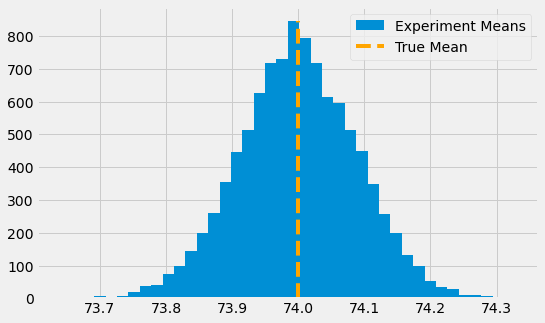

In [6]:
true_std = 2
true_mean = 74

n = 500
def run_experiment(): 
    return np.random.normal(true_mean,true_std, 500)

np.random.seed(42)

plt.figure(figsize=(8,5))
freq, bins, img = plt.hist([run_experiment().mean() for _ in range(10000)], bins=40, label="Experiment Means")
plt.vlines(true_mean, ymin=0, ymax=freq.max(), linestyles="dashed", label="True Mean", color="orange")
plt.legend();


This looks like a pretty extreme value. Indeed, it is above 2, which means there is less than a 5% chance that we would see such an extreme value if there were no difference in the groups. This again leads us to conclude that switching from face-to-face to online classes causes a statistically significant drop in academic performance.

One final interesting thing about hypothesis tests is that it is less conservative than checking if the 95% CI from the treated and untreated group overlaps. In other words, if the confidence intervals in the two groups overlap, it can still be the case that the result is statistically significant. For example, let's pretend that the face-to-face group has an average score of 80 with a standard error of 4, and the online group has an average score of 71 with a standard error of 2.

Questo assomiglia a un valore piuttosto estremo. Infatti, è superiore a 2, il che significa che c'è meno del 5% di possibilità di osservare un valore così estremo se non ci fosse differenza tra i gruppi. Questo di nuovo ci porta a concludere che il passaggio da classi faccia a faccia a classi online causa un calo statisticamente significativo nella prestazione accademica.

Una cosa finale interessante sui test di ipotesi è che è meno conservatore che controllare se il CI del 95% del gruppo trattato e non trattato si sovrappone. In altre parole, con un test di ipotesi, siamo più propensi a rifiutare l'ipotesi nulla.

If we construct the confidence intervals for these groups, they overlap. The upper bound for the 95% CI of the online group is 74.92, and the lower bound for the face-to-face group is 72.16. However, once we compute the 95% confidence interval for the difference between the groups, we can see that it does not contain zero. Even though the individual confidence intervals overlap, the difference can still be statistically different from zero.

## P-values

Previously, I've said that there is less than a 5% chance we would observe such an extreme value if the difference between online and face-to-face groups were actually zero. But can we precisely estimate what that chance is? How likely are we to observe such an extreme value? Enter p-values!

Like with confidence intervals (and most frequentist statistics, as a matter of fact), the true definition of p-values can be very confusing. So, to not take any risks, I'll copy the definition from Wikipedia: "the p-value is the probability of obtaining test results at least as extreme as the results actually observed during the test, assuming that the null hypothesis is correct". 

To put it more succinctly, the p-value is the probability of seeing such data, given that the null hypothesis is true. It measures how unlikely it is that you are seeing a measurement if the null hypothesis is true. Naturally, this often gets confused with the probability of the null hypothesis being true. Note the difference here. The p-value is NOT $P(H_0|data)$, but rather $P(data|H_0)$.

But don't let this complexity fool you. In practical terms, they are pretty straightforward to use.

![p_value](./data/img/stats-review/p_value.png)

To get the p-value, we need to compute the area under the standard normal distribution before or after the z statistic. Fortunately, we have a computer to do this calculation for us. We can simply plug the z statistic in the CDF of the standard normal distribution.

Se costruiamo gli intervalli di confidenza per questi gruppi, si sovrappongono. L'estremità superiore del CI del 95% del gruppo online è 74,92 e l'estremità inferiore per il gruppo faccia a faccia è 72,16. Tuttavia, una volta che calcoliamo l'intervallo di confidenza del 95% per la differenza tra i gruppi, vediamo che non contiene zero. Anche se i singoli intervalli di confidenza si sovrappongono, la differenza può comunque essere statisticamente diversa da zero.

## Valori P

Precedentemente, ho detto che c'è meno del 5% di possibilità di osservare questo valore z se l'ipotesi nulla fosse vera. Questo numero, il 5%, è il **p-value**. È la probabilità di osservare un risultato almeno altrettanto estremo come quello che abbiamo osservato, dato che l'ipotesi nulla è vera.

In [7]:
np.random.seed(321)
exp_data = run_experiment()
exp_se = exp_data.std() / np.sqrt(len(exp_data))
exp_mu = exp_data.mean()
ci = (exp_mu - 2 * exp_se, exp_mu + 2 * exp_se)
print(ci)

(73.82718114045632, 74.17341543460314)


Notice how the p-value is interesting because it avoids us having to specify a confidence level, like 95% or 99%. But, if we wish to report one, from the p-value, we know precisely at which confidence our test will pass or fail. For instance, with a p-value of 0.0027, we see that we have significance up to the 0.2% level. So, while the 95% CI and the 99% CI for the difference will neither contain zero, the 99.9% CI will. This means that there is only a 0.2% chance of observing this extreme z statistic if the difference was zero.

Nota come il p-value è interessante perché ci evita di dover specificare un livello di confidenza, come il 95% o il 99%. Ma, se desideriamo segnalarne uno, dal p-value, sappiamo precisamente a quale confidenza il nostro test passerà o fallirà. Ad esempio, con un p-value di 0,0027, vediamo che abbiamo significatività fino al livello dello 0,2%. Quindi, mentre il CI del 95% e il CI del 99% per la differenza non conterranno zero, il CI del 99,9% lo farà. Ciò significa che c'è solo uno 0,2% di possibilità di osservare questa statistica z così estrema.

## Key Ideas

We've seen how important it is to know Moivre’s equation, and we used it to place a degree of certainty around our estimates. Namely, we figured out that online classes cause a decrease in academic performance compared to face-to-face classes. We also saw that this was a statistically significant result. We did it by comparing the confidence intervals of the means for the 2 groups, looking at the confidence interval for the difference, doing a hypothesis test, and looking at the p-value. Let's wrap everything up in a single function that makes A/B testing comparison like the one we did above

## Idee Chiave

Abbiamo visto quanto sia importante conoscere l'equazione di Moivre, e l'abbiamo usata per determinare un grado di certezza attorno alle nostre stime. Vale a dire, abbiamo capito che le classi online causano una diminuzione della prestazione accademica rispetto alle classi faccia a faccia. Abbiamo anche visto che questo era un risultato statisticamente significativo. L'abbiamo fatto confrontando gli intervalli di confidenza delle medie per i 2 gruppi, guardando all'intervallo di confidenza per la differenza, eseguendo un test di ipotesi e guardando al p-value.

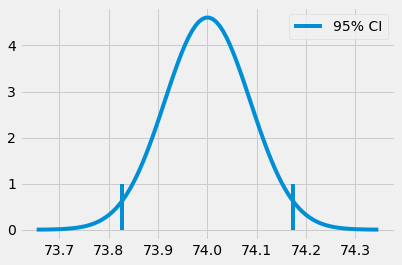

In [8]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=1)
plt.vlines(ci[0], ymin=0, ymax=1, label="95% CI")
plt.legend()
plt.show()

Since our function is generic enough, we can test other null hypotheses. For instance, can we try to reject that the difference between online and face-to-face class performance is -1? With the results we get, we can say with 95% confidence that the difference is more significant than -1. But we can't say it with 99% confidence:

Poiché la nostra funzione è abbastanza generica, possiamo testare altre ipotesi nulle. Ad esempio, possiamo provare a rifiutare che la differenza tra le prestazioni della classe online e faccia a faccia sia -1? Con i risultati che otteniamo, possiamo dire con il 95% di confidenza che la differenza è più significativa di -1. Ma non possiamo dirlo con il 99% di confidenza:

## References

I like to think of this entire book as a tribute to Joshua Angrist, Alberto Abadie and Christopher Walters for their amazing Econometrics class. Most of the ideas here are taken from their classes at the American Economic Association. Watching them is what is keeping me sane during this tough year of 2020.
* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)

I'll also like to reference the amazing books from Angrist. They have shown me that Econometrics, or 'Metrics as they call it, is not only extremely useful but also profoundly fun.

* [Mostly Harmless Econometrics](https://www.mostlyharmlesseconometrics.com/)
* [Mastering 'Metrics](https://www.masteringmetrics.com/)

My final reference is Miguel Hernan and Jamie Robins' book. It has been my trustworthy companion in the most thorny causal questions I had to answer.

* [Causal Inference Book](https://miguelhernan.org/whatifbook)

The data used here is from a study of Alpert, William T., Kenneth A. Couch, and Oskar R. Harmon. 2016. ["A Randomized Assessment of Online Learning"](https://www.aeaweb.org/articles?id=10.1257/aer.p20161057). American Economic Review, 106 (5): 378-82.

![img](./data/img/poetry.png)

## Contribute

Causal Inference for the Brave and True is an open-source material on causal inference, the statistics of science. Its goal is to be accessible monetarily and intellectually. It uses only free software based on Python.
If you found this book valuable and want to support it, please go to [Patreon](https://www.patreon.com/causal_inference_for_the_brave_and_true). If you are not ready to contribute financially, you can also help by fixing typos, suggesting edits, or giving feedback on passages you didn't understand. Go to the book's repository and [open an issue](https://github.com/matheusfacure/python-causality-handbook/issues). Finally, if you liked this content, please share it with others who might find it helpful and give it a [star on GitHub](https://github.com/matheusfacure/python-causality-handbook/stargazers).

## Riferimenti

Penso a questo intero libro come un tributo a Joshua Angrist, Alberto Abadie e Christopher Walters per la loro incredibile classe di Econometria. La maggior parte delle idee qui sono prese dalle loro classi presso l'American Economic Association. Guardarli è quello che mi tiene sano durante questo difficile anno 2020.
* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)
* [Joshua Angrist's MIT Class](https://economics.mit.edu/faculty/angrist)
* [Book Website](https://matheusfacure.github.io/causal-inference-for-the-brave-and-true/)

In [9]:
from scipy import stats
z = stats.norm.ppf(.995)
print(z)
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci

2.5758293035489004


(73.7773381773405, 74.22325839771896)

## References

I like to think of this entire book as a tribute to Joshua Angrist, Alberto Abadie and Christopher Walters for their amazing Econometrics class. Most of the ideas here are taken from their classes at the American Economic Association. Watching them is what is keeping me sane during this tough year of 2020.
* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)

I'll also like to reference the amazing books from Angrist. They have shown me that Econometrics, or 'Metrics as they call it, is not only extremely useful but also profoundly fun.

* [Mostly Harmless Econometrics](https://www.mostlyharmlesseconometrics.com/)
* [Mastering 'Metrics](https://www.masteringmetrics.com/)

My final reference is Miguel Hernan and Jamie Robins' book. It has been my trustworthy companion in the most thorny causal questions I had to answer.

* [Causal Inference Book](https://miguelhernan.org/whatifbook)

The data used here is from a study of Alpert, William T., Kenneth A. Couch, and Oskar R. Harmon. 2016. ["A Randomized Assessment of Online Learning"](https://www.aeaweb.org/articles?id=10.1257/aer.p20161057). American Economic Review, 106 (5): 378-82.

![img](./data/img/poetry.png)

## Contribute

inferenza causale for the Brave and True is an open-source material on inferenza causale, the statistics of science. Its goal is to be accessible monetarily and intellectually. It uses only free software based on Python.
If you found this book valuable and want to support it, please go to [Patreon](https://www.patreon.com/causal_inference_for_the_brave_and_true). If you are not ready to contribute financially, you can also help by fixing typos, suggesting edits, or giving feedback on passages you didn't understand. Go to the book's repository and [open an issue](https://github.com/matheusfacure/python-causality-handbook/issues). Finally, if you liked this content, please share it with others who might find it helpful and give it a [star on GitHub](https://github.com/matheusfacure/python-causality-handbook/stargazers).

## Riferimenti

Penso a questo intero libro come un tributo a Joshua Angrist, Alberto Abadie e Christopher Walters per la loro incredibile classe di Econometria. La maggior parte delle idee qui sono prese dalle loro classi presso l'American Economic Association. Guardarli è quello che mi tiene sano durante questo difficile anno 2020.
* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)
* [Joshua Angrist's MIT Class](https://economics.mit.edu/faculty/angrist)
* [Book Website](https://matheusfacure.github.io/causal-inference-for-the-brave-and-true/)

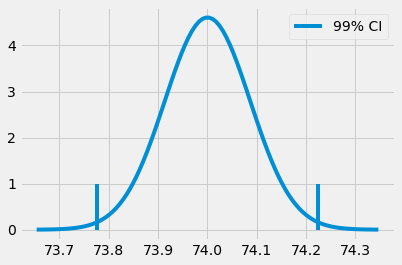

In [10]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=1)
plt.vlines(ci[0], ymin=0, ymax=1, label="99% CI")
plt.legend()
plt.show()

In [11]:
def ci(y: pd.Series):
    return (y.mean() - 2 * se(y), y.mean() + 2 * se(y))

print("95% CI for Online:", ci(online))
print("95% for Face to Face:", ci(face_to_face))

95% CI for Online: (70.56094429049804, 76.7095818797147)
95% for Face to Face: (76.80278229206951, 80.29218687459715)


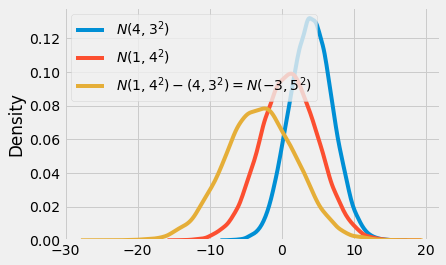

In [12]:
np.random.seed(123)
n1 = np.random.normal(4, 3, 30000)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1
sns.distplot(n1, hist=False, label="$N(4,3^2)$")
sns.distplot(n2, hist=False, label="$N(1,4^2)$")
sns.distplot(n_diff, hist=False, label=f"$N(1,4^2) - (4,3^2) = N(-3, 5^2)$")
plt.legend()
plt.show()

In [13]:
diff_mu = online.mean() - face_to_face.mean()
diff_se = np.sqrt(face_to_face.var()/len(face_to_face) + online.var()/len(online))
ci = (diff_mu - 1.96*diff_se, diff_mu + 1.96*diff_se)
print(ci)

(-8.376410208363385, -1.4480327880905248)


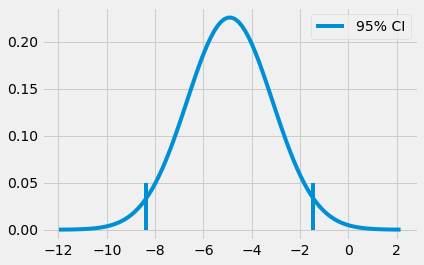

In [14]:
x = np.linspace(diff_mu - 4*diff_se, diff_mu + 4*diff_se, 100)
y = stats.norm.pdf(x, diff_mu, diff_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=.05)
plt.vlines(ci[0], ymin=0, ymax=.05, label="95% CI")
plt.legend()
plt.show()

In [15]:
z = diff_mu / diff_se
print(z)

-2.7792810791031224


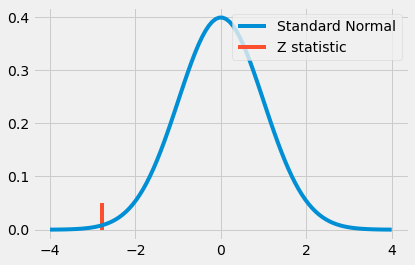

In [16]:
x = np.linspace(-4,4,100)
y = stats.norm.pdf(x, 0, 1)
plt.plot(x, y, label="Standard Normal")
plt.vlines(z, ymin=0, ymax=.05, label="Z statistic", color="C1")
plt.legend()
plt.show()

In [17]:
cont_mu, cont_se =  (71, 2)
test_mu, test_se = (80, 4)

diff_mu = test_mu - cont_mu
diff_se = np.sqrt(cont_se**2 + test_se**2)

print("Control 95% CI:", (cont_mu-1.96*cont_se, cont_mu+1.96*cont_se))
print("Test 95% CI:", (test_mu-1.96*test_se, test_mu+1.96*test_se))
print("Diff 95% CI:", (diff_mu-1.96*diff_se, diff_mu+1.96*diff_se))

Control 95% CI: (67.08, 74.92)
Test 95% CI: (72.16, 87.84)
Diff 95% CI: (0.23461352820082482, 17.765386471799175)


In [18]:
print("P-value:", stats.norm.cdf(z))

P-value: 0.0027239680835563383


In [19]:
diff_mu = online.mean() - face_to_face.mean()
diff_se = np.sqrt(face_to_face.var()/len(face_to_face) + online.var()/len(online))
print("95% CI:", (diff_mu - stats.norm.ppf(.975)*diff_se, diff_mu + stats.norm.ppf(.975)*diff_se))
print("99% CI:", (diff_mu - stats.norm.ppf(.995)*diff_se, diff_mu + stats.norm.ppf(.995)*diff_se))
print("99.9% CI:", (diff_mu - stats.norm.ppf(.9995)*diff_se, diff_mu + stats.norm.ppf(.9995)*diff_se))

95% CI: (-8.376346553082909, -1.4480964433710017)
99% CI: (-9.46485353526404, -0.3595894611898709)
99.9% CI: (-10.728040658245558, 0.9035976617916459)


In [20]:
def AB_test(test: pd.Series, control: pd.Series, confidence=0.95, h0=0):
    mu1, mu2 = test.mean(), control.mean()
    se1, se2 = test.std() / np.sqrt(len(test)), control.std() / np.sqrt(len(control))
    
    diff = mu1 - mu2
    se_diff = np.sqrt(test.var()/len(test) + control.var()/len(control))
    
    z_stats = (diff-h0)/se_diff
    p_value = stats.norm.cdf(z_stats)
    
    def critical(se): return -se*stats.norm.ppf((1 - confidence)/2)
    
    print(f"Test {confidence*100}% CI: {mu1} +- {critical(se1)}")
    print(f"Control {confidence*100}% CI: {mu2} +- {critical(se2)}")
    print(f"Test-Control {confidence*100}% CI: {diff} +- {critical(se_diff)}")
    print(f"Z Statistic {z_stats}")
    print(f"P-Value {p_value}")
        
AB_test(online, face_to_face)

Test 95.0% CI: 73.63526308510637 +- 3.0127770572134565
Control 95.0% CI: 78.54748458333333 +- 1.7097768273108005
Test-Control 95.0% CI: -4.912221498226955 +- 3.4641250548559537
Z Statistic -2.7792810791031224
P-Value 0.0027239680835563383


In [21]:
AB_test(online, face_to_face, h0=-1)

Test 95.0% CI: 73.63526308510637 +- 3.0127770572134565
Control 95.0% CI: 78.54748458333333 +- 1.7097768273108005
Test-Control 95.0% CI: -4.912221498226955 +- 3.4641250548559537
Z Statistic -2.2134920404560883
P-Value 0.013431870694630114
